In [9]:
# Imports for data exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [10]:
# Setting up data directory
data_dir = Path("data")

In [11]:
# Load train.csv file from data directory
train_file = data_dir / "train.csv"
training_data = pd.read_csv(train_file)


In [12]:
import os
print(os.getcwd())

c:\Users\Kshitij\OneDrive\Desktop\Major project\mitadtu-docking


In [13]:
# training data columns
training_data.columns
# sample rows
training_data.head()

,ImageID,distance,location
0,0,351,"[215, 158]"
1,1,372,"[228, 269]"
2,2,488,"[255, 386]"
3,3,308,"[306, 426]"
4,4,67,"[248, 338]"


Distance: 351, Location: [215, 158]


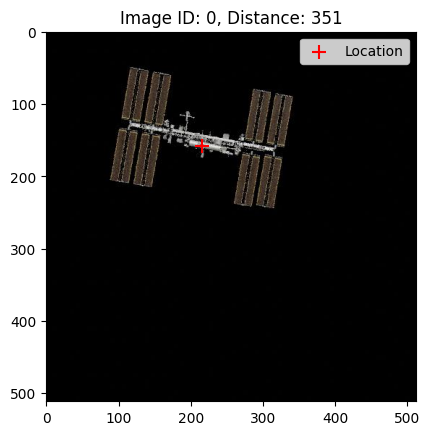

In [14]:
# Display a sample jpg image from data/train and the corresponding distance and location from trining_data
# # Overlay a red point on the image at the location specified in training_data
# Set image id
image_id = 0
# Load the image
image_file = data_dir / "train" / f"{image_id}.jpg"
image = plt.imread(image_file)
# Display the image
plt.imshow(image)
# Get the corresponding distance and location from training_data
distance = training_data.loc[image_id, 'distance']
location_str = training_data.loc[image_id, 'location']
# Convert location string '[244, 102]' to tuple (244, 102)
import ast
location = ast.literal_eval(location_str)
# Overlay a red crosshair on the image at the location specified in training_data
plt.scatter(location[0], location[1], color='red', s=100, marker='+', label='Location')
plt.title(f"Image ID: {image_id}, Distance: {distance}")
print(f"Distance: {distance}, Location: {location}")
plt.legend()
plt.show()

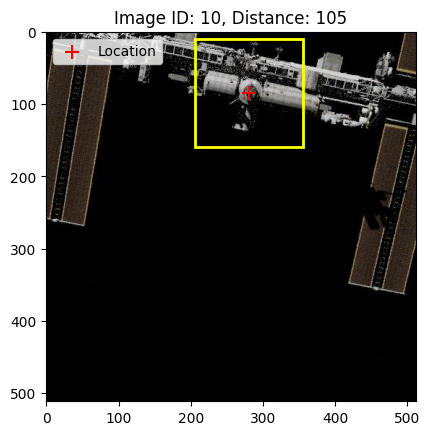

In [20]:
import matplotlib.patches as patches

# Enter the image id you want to display
image_id = 10  

# Load image
image_file = data_dir / "train" / f"{image_id}.jpg"
image = plt.imread(image_file)

# Show image
plt.imshow(image)

# Get distance and location from training_data
distance = training_data.loc[image_id, 'distance']
location_str = training_data.loc[image_id, 'location']
location = ast.literal_eval(location_str)

# Red cross at object location
plt.scatter(location[0], location[1], color='red', s=100, marker='+', label='Location')

# Draw bounding box around object
box_size = 150   
x = location[0] - box_size/2
y = location[1] - box_size/2

rect = patches.Rectangle((x, y), box_size, box_size,
                         linewidth=2, edgecolor='yellow', facecolor='none')
plt.gca().add_patch(rect)

# Title & legend
plt.title(f"Image ID: {image_id}, Distance: {distance}")
plt.legend()
plt.show()


Velocity from Image 1 → 5: [15.5 83.5]
Velocity from Image 5 → 7: [  20.5 -138.5]

Change in velocity (Δv) between first and second intervals: 222.05629916757596


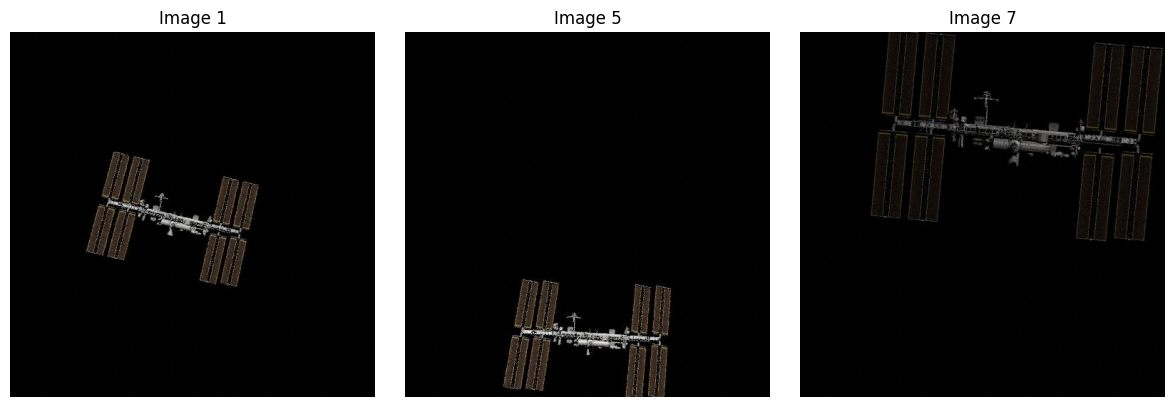

In [26]:
# Choose images
image_ids = [1, 5, 7]   
delta_t = 2.0          # time difference between images in sec

# Get locations for each image
locations = []
for img_id in image_ids:
    loc_str = training_data.loc[img_id, 'location']
    loc = ast.literal_eval(loc_str)
    locations.append(np.array(loc))

# Compute velocities between consecutive pairs
velocities = []
for i in range(len(locations)-1):
    displacement = locations[i+1] - locations[i]
    velocity = displacement / delta_t
    velocities.append(velocity)
    print(f"Velocity from Image {image_ids[i]} → {image_ids[i+1]}: {velocity}")

# Compute velocity change (delta-v)
if len(velocities) > 1:
    delta_v = np.linalg.norm(velocities[1] - velocities[0])
    print(f"\nChange in velocity (Δv) between first and second intervals: {delta_v}")

# Show the images
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i, img_id in enumerate(image_ids):
    plt.subplot(1, len(image_ids), i+1)
    img = plt.imread(data_dir / "train" / f"{img_id}.jpg")
    plt.imshow(img)
    plt.title(f"Image {img_id}")
    plt.axis("off")
plt.tight_layout()
plt.show()


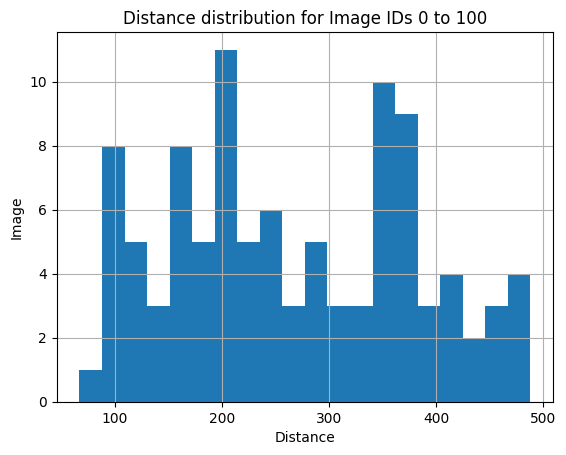

In [34]:
# Enter images for range
start_id = 0
end_id = 100 

# Filter training data for this range
subset = training_data.loc[start_id:end_id]

# Plot histogram of distances in this range
subset['distance'].hist(bins=20)
plt.xlabel("Distance")
plt.ylabel("Image")
plt.title(f"Distance distribution for Image IDs {start_id} to {end_id}")
plt.show()


In [ ]:
# Enter images for range
start_id = 1
end_id = 10 

# Calculate orientation 